#### 성적 데이터 생성

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.DataFrame(
    {'시간' : [2,4,8,9],
    '성적' : [20,40,80,90]}
)
data

,시간,성적
0,2,20
1,4,40
2,8,80
3,9,90


w와 b를 찾는 법
- 최소제곱법 : 수학적 공식을 이용한 해석적 방법
- 경사하강법 : w와 b값의 변화에 따른 오차값의 기울기를 이용하여 찾는 방법

최소제곱법이 적용된 sklearn 모델 사용해보기!

In [4]:
from sklearn.linear_model import LinearRegression

In [6]:
#모델 생성
lr_rg = LinearRegression() #선형회귀는 하이퍼 파라미터 없음

In [8]:
#학습
lr_rg.fit(data[['시간']], data['성적'])  #시간을 리스트로 감싸주는 건 왜 그런거지?

LinearRegression()

In [9]:
# 예측
lr_rg.predict([[7]])

C:\Users\smhrd\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([70.])

In [11]:
# 가중치(w), 절편(b) 확인 : .coef_
lr_rg.coef_

array([10.])

In [13]:
lr_rg.intercept_ #y =ax+b의 b,  e-15= 7.105 앞에 0 15개있음

7.105427357601002e-15

#### 경사하강법(Gradient Descent)
1. 파라미터(w,b) 초기화 : 임의의 값으로
2. 예측 : 현재 w와 b를 사용해서 예측을 수행
3. 오차 계산 : 예측값과 실제값 사이의 오차 계산 -> MSE
4. 비용함수의 기울기 계산 : 오차값이 낮아지는 방향을 찾기 위해서, w와 mse 간의 기울기 값을 계산
5. 파라미터 업데이트 : 기울기와 학습률을 사용해서 업데이트

In [14]:
# 가설함수 정의 
# 예측값
def h(w,x)  : 
    return w*x + 0 

In [15]:
# MSE 평균제곱오차 : 손실함수, 비용 함수 
def cost(data, target, weight) :  #특성(시간), 실제값(실제 성적), 가중치
    y_pred = h(weight, data)
    mse = ((target - y_pred)**2).mean()
    return mse

In [16]:
# MSE
cost(data['시간'], data['성적'], 10)

0.0

- w값에 따른 mse 변화율 그려보기

In [17]:
# x축의 범위
w_arr = range(-10,31) # -10~-30

In [20]:
cost_list = [] # 비용함수 mse를 담아줄 리스트
for w in w_arr : 
    c = cost(data['시간'], data['성적'], w)
    cost_list.append(c)
cost_list

[16500.0,
 14891.25,
 13365.0,
 11921.25,
 10560.0,
 9281.25,
 8085.0,
 6971.25,
 5940.0,
 4991.25,
 4125.0,
 3341.25,
 2640.0,
 2021.25,
 1485.0,
 1031.25,
 660.0,
 371.25,
 165.0,
 41.25,
 0.0,
 41.25,
 165.0,
 371.25,
 660.0,
 1031.25,
 1485.0,
 2021.25,
 2640.0,
 3341.25,
 4125.0,
 4991.25,
 5940.0,
 6971.25,
 8085.0,
 9281.25,
 10560.0,
 11921.25,
 13365.0,
 14891.25,
 16500.0]

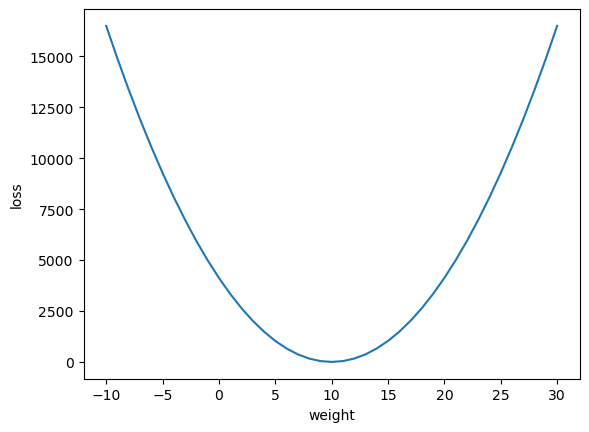

In [24]:
plt.plot(w_arr, cost_list)
plt.xlabel('weight')
plt.ylabel('loss')
plt.show()

In [25]:
# 확률적 경사하강법이 적용된 모델 
from sklearn.linear_model import SGDRegressor

In [27]:
#모델 초기화(생성)
sgd_rg = SGDRegressor(
    eta0= 0.01, # 학습률, 기울기의 보폭
    max_iter= 5000, # w값을 업데이트하는 횟수 최대 5000번까지 수행
    verbose = 1 # 학습 진행 현황 출력
)

In [29]:
#학습
sgd_rg.fit(data[['시간']], data['성적'])

-- Epoch 1
Norm: 8.62, NNZs: 1, Bias: 1.143618, T: 4, Avg. loss: 917.008178
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 9.52, NNZs: 1, Bias: 1.268138, T: 8, Avg. loss: 16.924296
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 9.73, NNZs: 1, Bias: 1.294441, T: 12, Avg. loss: 1.328848
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 9.80, NNZs: 1, Bias: 1.297415, T: 16, Avg. loss: 0.295372
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 9.82, NNZs: 1, Bias: 1.295453, T: 20, Avg. loss: 0.192128
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 9.83, NNZs: 1, Bias: 1.291998, T: 24, Avg. loss: 0.176903
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 9.83, NNZs: 1, Bias: 1.287399, T: 28, Avg. loss: 0.176845
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 9.83, NNZs: 1, Bias: 1.283196, T: 32, Avg. loss: 0.175225
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 9.83, NNZs: 1, Bias: 1.279221, T: 36, Avg. loss: 0.172256
Total training time: 0.00 seconds.
-- Epoch 

SGDRegressor(max_iter=5000, verbose=1)

In [30]:
#가중치와 절편 확인 
sgd_rg.coef_, sgd_rg.intercept_

(array([9.8485063]), array([1.11950678]))

In [33]:
# 성능 확인, 회귀에서는 R2score 
sgd_rg.score(data[['시간']], data['성적'])
#회귀 평자 지표(오차값, 데이터의 분포를 잘 이해하고 있는가?)
# 분류 평가 지표 (얼마나 잘 맞췄는가?)

0.9996951237566573